DATASET OVERVIEW
Dataset Shape: (1470, 35)

First 10 Rows
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences  

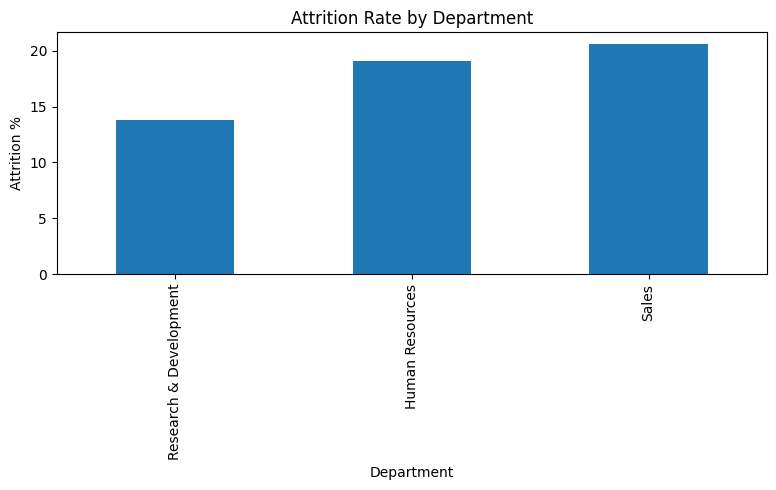

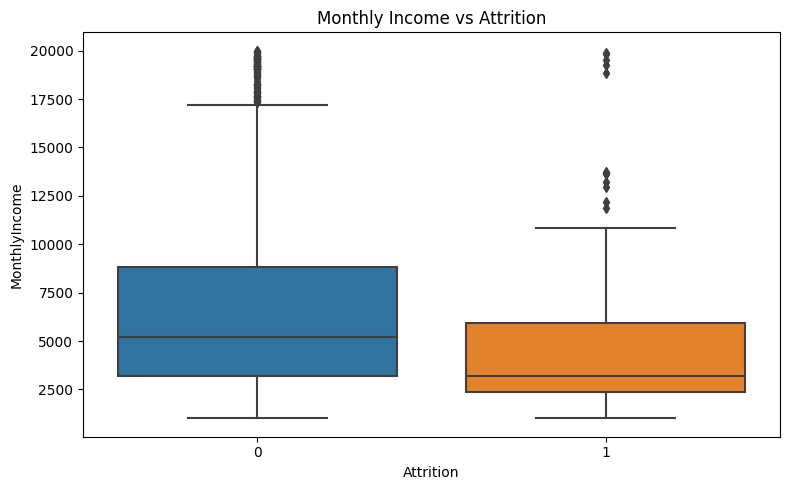


Attrition by Job Role (%)
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: 1, dtype: float64

Work Life Balance vs Attrition
Attrition                0          1
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059

Years At Company Summary
            count      mean       std  min  25%  50%   75%   max
Attrition                                                       
0          1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
1           237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0

Training Models...

Logistic Regression
   

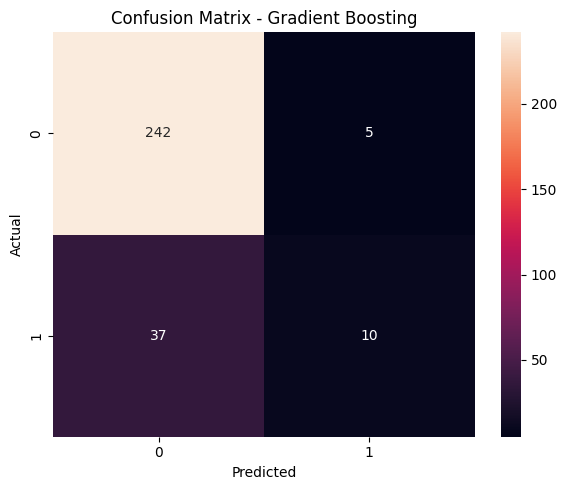


Top 10 Important Features
                         Feature  Importance
37            num__MonthlyIncome    0.103624
28                      num__Age    0.099523
44        num__TotalWorkingYears    0.083994
27             cat__OverTime_Yes    0.063801
43         num__StockOptionLevel    0.049946
39       num__NumCompaniesWorked    0.048832
50     num__YearsWithCurrManager    0.044073
29                num__DailyRate    0.041876
32  num__EnvironmentSatisfaction    0.039871
34           num__JobInvolvement    0.039142


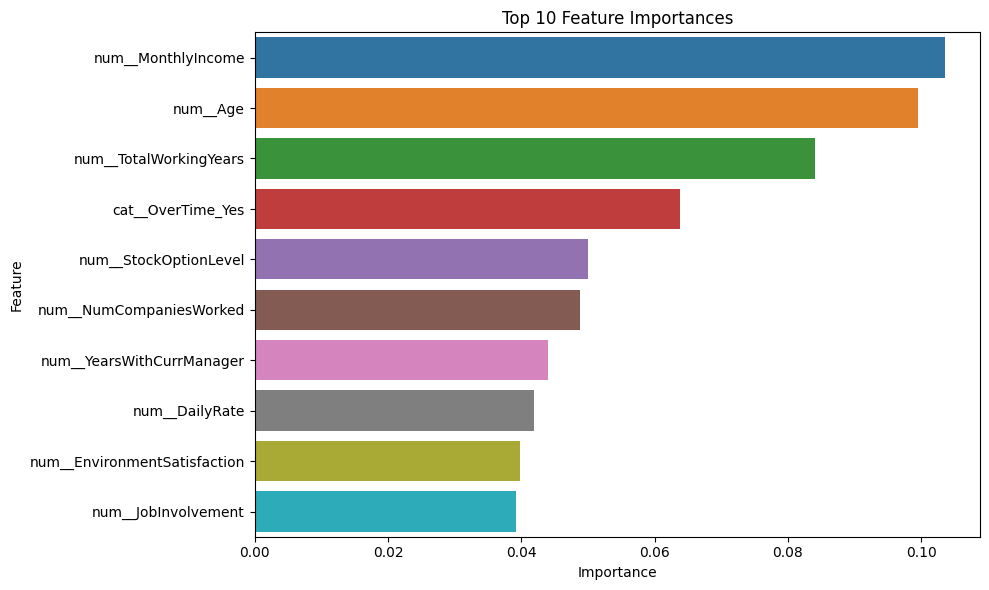

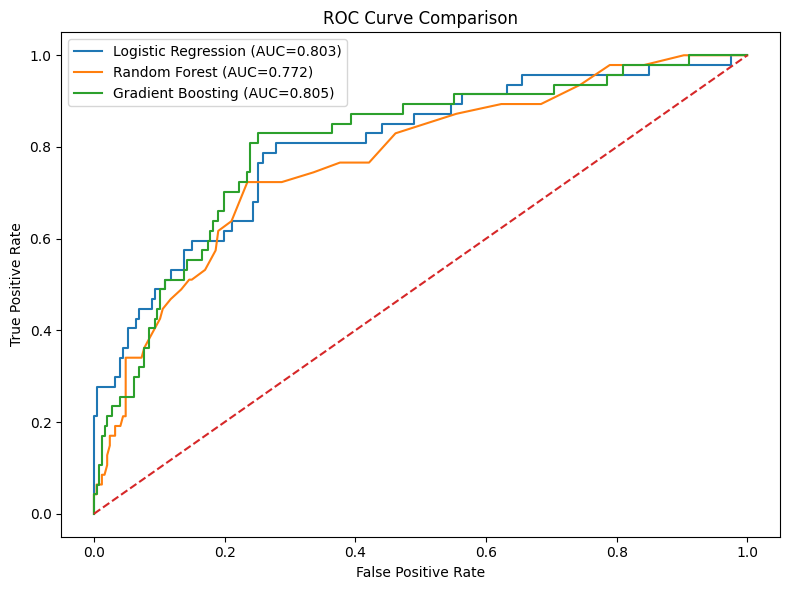


HR INSIGHTS & RECOMMENDATIONS

1. Employees with lower income show higher attrition.

2. Certain job roles experience significantly higher turnover.

3. Employees in their early years at the company are more likely to leave.

4. Work-life balance and job satisfaction influence retention.

5. HR should focus retention efforts on high-risk roles and newer employees.

Recommendations:
- Improve career growth opportunities.
- Conduct retention discussions with high-risk employees.
- Strengthen work-life balance programs.
- Review compensation and overtime policies.



In [ ]:
# ============================================================
# EMPLOYEE ATTRITION PREDICTION PROJECT
# XYLOFY AI - WEEK 2 INTERNSHIP
# ============================================================
# =========================
# IMPORT LIBRARIES
# =========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# TASK 1 - DATA LOADING & EXPLORATION
# ============================================================

df = pd.read_csv("HR_Attrition.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("Dataset Shape:", df.shape)

print("\nFirst 10 Rows")
print(df.head(10))

print("\nAttrition Counts")
print(df["Attrition"].value_counts())

attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)["Yes"] * 100
)

print(f"\nAttrition Rate: {attrition_rate:.2f}%")

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("\nNumeric Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

# ============================================================
# TASK 2 - DATA CLEANING & PREPROCESSING
# ============================================================

print("\nMissing Values")
print(df.isnull().sum())

drop_cols = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

categorical_features = X.select_dtypes(
    include="object"
).columns

numerical_features = X.select_dtypes(
    include=np.number
).columns

preprocessor = ColumnTransformer([
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "num",
        StandardScaler(),
        numerical_features
    )
])

# ============================================================
# TASK 3 - EDA
# ============================================================

# Chart 1 - Department Attrition

dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

plt.figure(figsize=(8,5))
dept_attrition[1].sort_values().plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition %")
plt.tight_layout()
plt.savefig("charts/attrition_department.png",dpi=300,bbox_inches="tight")
plt.show()

# Chart 2 - Income Boxplot

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)
plt.title("Monthly Income vs Attrition")
plt.tight_layout()
plt.savefig("charts/income_boxplot.png",dpi=300,bbox_inches="tight")
plt.show()

# Attrition by Job Role

print("\nAttrition by Job Role (%)")

job_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(
    job_attrition[1]
    .sort_values(ascending=False)
)

# Work Life Balance Analysis

print("\nWork Life Balance vs Attrition")

print(
    pd.crosstab(
        df["WorkLifeBalance"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

# Years At Company

print("\nYears At Company Summary")

print(
    df.groupby("Attrition")[
        "YearsAtCompany"
    ].describe()
)

# ============================================================
# TASK 4 - MODEL BUILDING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

lr_model = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

rf_model = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        )
    )
])

gb_model = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

print("\nTraining Models...")

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# ============================================================
# TASK 5 - MODEL EVALUATION
# ============================================================

results = []

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

predictions = {}
probabilities = {}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        precision,
        recall,
        f1,
        roc
    ])

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

print("\nMODEL COMPARISON")
print(results_df)

# ============================================================
# BEST MODEL
# ============================================================

best_model_name = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]["Model"]

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]
best_pred = predictions[best_model_name]

# ============================================================
# CHART 3 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("charts/confusion_matrix.png",dpi=300,bbox_inches="tight")
plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_names = (
    best_model.named_steps["prep"]
    .get_feature_names_out()
)

if hasattr(
    best_model.named_steps["model"],
    "feature_importances_"
):
    importance = (
        best_model.named_steps["model"]
        .feature_importances_
    )
else:
    importance = np.abs(
        best_model.named_steps["model"]
        .coef_[0]
    )

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

top10 = feature_df.head(10)

print("\nTop 10 Important Features")
print(top10)

# ============================================================
# CHART 4 - FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("charts/feature_importance.png",dpi=300,bbox_inches="tight")
plt.show()

# ============================================================
# CHART 5 - ROC CURVE
# ============================================================

plt.figure(figsize=(8,6))

for name in models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("charts/roc_curve.png", dpi=300,bbox_inches="tight")
plt.show()

# ============================================================
# TASK 7 - HR INSIGHTS
# ============================================================

print("\n" + "="*60)
print("HR INSIGHTS & RECOMMENDATIONS")
print("="*60)

print("""
1. Employees with lower income show higher attrition.

2. Certain job roles experience significantly higher turnover.

3. Employees in their early years at the company are more likely to leave.

4. Work-life balance and job satisfaction influence retention.

5. HR should focus retention efforts on high-risk roles and newer employees.

Recommendations:
- Improve career growth opportunities.
- Conduct retention discussions with high-risk employees.
- Strengthen work-life balance programs.
- Review compensation and overtime policies.
""")

